In [ ]:
# Load required libraries
library(brms)
library(tidyverse)
library(ggplot2)
library(bayesplot)

# Set seed for reproducibility

# Generate synthetic data with NO relationship
n <- 3000
quantiles <- c(0.5, 0.7, 0.9, 0.95, 0.97, 0.99)


In [19]:
set.seed(420)

# Generate completely independent variables
synthetic_data <- tibble(
    # Predictor variables (independent)
    x1 = rnorm(n, mean = 5, sd = 2),
    x2 = runif(n, min = 0, max = 10),
    x3 = rexp(n, rate = 0.2),

    # Response variable (independent of predictors)
    y = rnorm(n, mean = 10, sd = 3)
)

# Verify no correlation exists
cat("Correlation matrix (should be near zero):\n")
print(round(cor(synthetic_data), 4))


Correlation matrix (should be near zero):
        x1      x2      x3       y
x1  1.0000 -0.0004  0.0543 -0.0608
x2 -0.0004  1.0000  0.0301  0.0217
x3  0.0543  0.0301  1.0000 -0.0464
y  -0.0608  0.0217 -0.0464  1.0000


In [20]:
results <- tibble(
    quantile = numeric(),
    bayes_r2_mean = numeric(),
    bayes_r2_lower = numeric(),
    bayes_r2_upper = numeric(),
    model = list()
)


cat("Running Bayesian quantile regressions...\n")

# Loop through each quantile
for (i in seq_along(quantiles)) {
    q <- quantiles[i]

    print(paste("Processing", q))

    # Fit Bayesian quantile regression
    model <- brm(
        brms::bf(y ~ x1 + x2 + x3, quantile = q),
        data = synthetic_data,
        family = asym_laplace(),
        prior = c(
            prior(normal(0, 5), class = Intercept),
            prior(normal(0, 2), class = b)
        ),
        iter = 2000,
        warmup = 1000,
        chains = 4,
        cores = 4,
        threads = threading(2),
        seed = 42 + i,
        refresh = 0, # Suppress output
        silent = 2 # Suppress warnings
    )

    # Calculate Bayes R²
    bayes_r2_samples <- bayes_R2(model)
    bayes_r2_summary <- posterior_summary(bayes_r2_samples)

    # Store results
    results <- results %>%
        add_row(
            quantile = q,
            bayes_r2_mean = bayes_r2_summary[1, "Estimate"],
            bayes_r2_lower = bayes_r2_summary[1, "Q2.5"],
            bayes_r2_upper = bayes_r2_summary[1, "Q97.5"],
            model = list(model)
        )
}


Running Bayesian quantile regressions...
[1] "Processing 0.5"
[1] "Processing 0.7"
[1] "Processing 0.9"
[1] "Processing 0.95"
[1] "Processing 0.97"
[1] "Processing 0.99"


In [21]:
print(results |> select(-model))


# A tibble: 6 × 4
  quantile bayes_r2_mean bayes_r2_lower bayes_r2_upper
     <dbl>         <dbl>          <dbl>          <dbl>
1     0.5        0.00787        0.00787        0.00787
2     0.7        0.00926        0.00926        0.00926
3     0.9        0.0172         0.0172         0.0172 
4     0.95       0.0261         0.0261         0.0261 
5     0.97       0.0213         0.0213         0.0213 
6     0.99       0.0686         0.0686         0.0686 



Summary Statistics:
Mean Bayes R² across all quantiles: 0.0251
SD of Bayes R² across quantiles: 0.0224
Min Bayes R²: 0.0079 (at quantile 0.50)
Max Bayes R²: 0.0686 (at quantile 0.99)


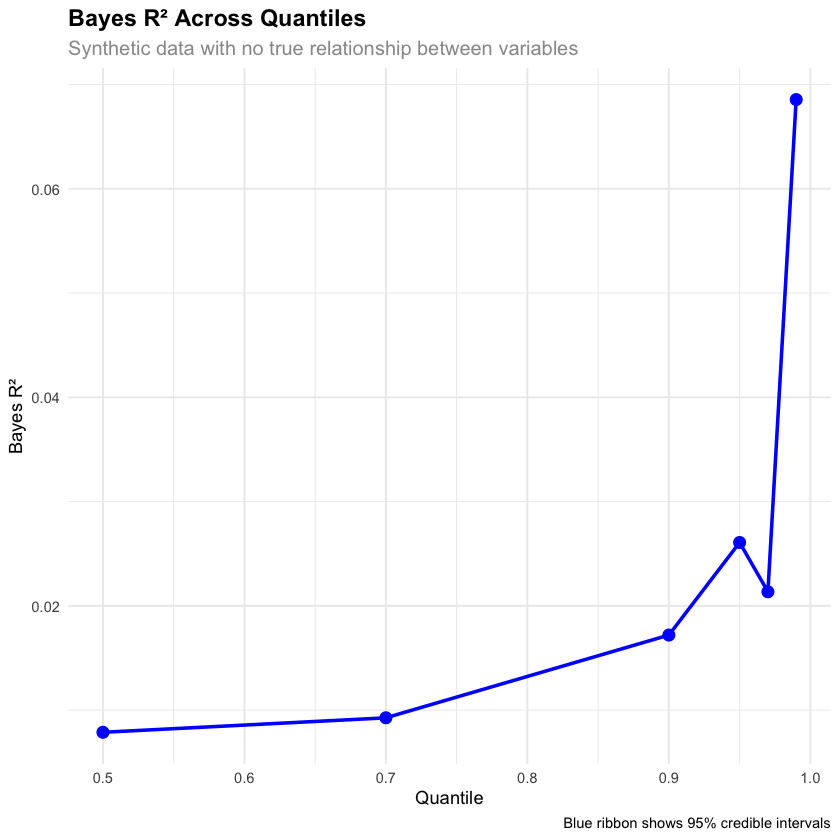

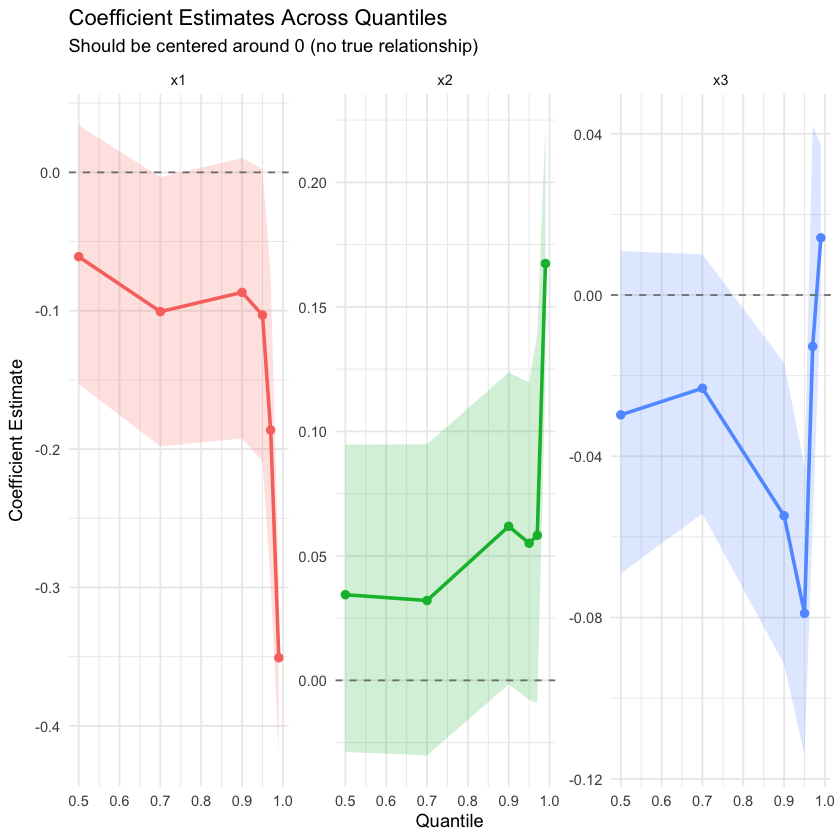

In [22]:
# Create visualization
p1 <- ggplot(results, aes(x = quantile, y = bayes_r2_mean)) +
    geom_line(color = "blue", size = 1) +
    geom_point(color = "blue", size = 3) +
    geom_ribbon(aes(ymin = bayes_r2_lower, ymax = bayes_r2_upper),
        alpha = 0.2, fill = "blue"
    ) +
    labs(
        title = "Bayes R² Across Quantiles",
        subtitle = "Synthetic data with no true relationship between variables",
        x = "Quantile",
        y = "Bayes R²",
        caption = "Blue ribbon shows 95% credible intervals"
    ) +
    theme_minimal() +
    theme(
        plot.title = element_text(size = 14, face = "bold"),
        plot.subtitle = element_text(size = 12, color = "gray60")
    )

print(p1)

# Summary statistics
cat("\nSummary Statistics:\n")
cat(sprintf("Mean Bayes R² across all quantiles: %.4f\n", mean(results$bayes_r2_mean)))
cat(sprintf("SD of Bayes R² across quantiles: %.4f\n", sd(results$bayes_r2_mean)))
cat(sprintf(
    "Min Bayes R²: %.4f (at quantile %.2f)\n",
    min(results$bayes_r2_mean),
    results$quantile[which.min(results$bayes_r2_mean)]
))
cat(sprintf(
    "Max Bayes R²: %.4f (at quantile %.2f)\n",
    max(results$bayes_r2_mean),
    results$quantile[which.max(results$bayes_r2_mean)]
))


# Create a comparison plot of coefficient estimates across quantiles
coef_results <- tibble(
    quantile = numeric(),
    parameter = character(),
    estimate = numeric(),
    lower = numeric(),
    upper = numeric()
)

for (i in seq_along(quantiles)) {
    model_summary <- posterior_summary(results$model[[i]])

    # Extract coefficient estimates (excluding intercept and sigma)
    coef_rows <- grep("^b_[^I]", rownames(model_summary))

    for (j in coef_rows) {
        param_name <- gsub("b_", "", rownames(model_summary)[j])

        coef_results <- coef_results %>%
            add_row(
                quantile = quantiles[i],
                parameter = param_name,
                estimate = model_summary[j, "Estimate"],
                lower = model_summary[j, "Q2.5"],
                upper = model_summary[j, "Q97.5"]
            )
    }
}

# Plot coefficient estimates across quantiles
p3 <- ggplot(coef_results, aes(x = quantile, y = estimate, color = parameter)) +
    geom_line(size = 1) +
    geom_point(size = 2) +
    geom_ribbon(aes(ymin = lower, ymax = upper, fill = parameter),
        alpha = 0.2, color = NA
    ) +
    geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
    facet_wrap(~parameter, scales = "free_y") +
    labs(
        title = "Coefficient Estimates Across Quantiles",
        subtitle = "Should be centered around 0 (no true relationship)",
        x = "Quantile",
        y = "Coefficient Estimate"
    ) +
    theme_minimal() +
    theme(legend.position = "none")

print(p3)
